# Loading required packages

In [1]:
import numpy as np
import cozipy as czp
import pandas as pd
import scanpy as sc
import os
import pathlib
from utils.cozi_dotplot import cozi_dotplot_facet_split
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from scipy.sparse import coo_matrix
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["text.color"] = "black"
mpl.rcParams["axes.labelcolor"] = "black"
mpl.rcParams["xtick.color"] = "black"
mpl.rcParams["ytick.color"] = "black"

# Paths

In [2]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_6"

# Load the necessary data

In [3]:
adata = sc.read_h5ad(os.path.join(data_dir, "adata.h5ad"))

# Run cozipy for cell-cell colocalization

In [4]:
all_long = []

for pt in adata.obs["patient_exp"].unique():
    adata_select = adata[adata.obs["patient_exp"] == pt].copy()

    results = czp.run_cozi(
        coords=adata_select.obs[["Cell Center X", "Cell Center Y"]].values,
        labels=adata_select.obs["cell_category"].values,
        nbh_def="delaunay",
        n_permutations=100,
        random_state=42,
            )

    # results["cond_ratio"] and results["zscore"] are DataFrames (because return_df=True by default)
    cond_df = results["cond_ratio"].copy()
    z_df = results["zscore"].copy()

    # Long format
    cond_long = (
        cond_df.stack(dropna=False)
        .rename("cond_ratio")
        .reset_index()
        .rename(columns={"level_0": "celltype_A", "level_1": "celltype_B"})
    )
    z_long = (
        z_df.stack(dropna=False)
        .rename("zscore")
        .reset_index()
        .rename(columns={"level_0": "celltype_A", "level_1": "celltype_B"})
    )

    long_df = cond_long.merge(z_long, on=["celltype_A", "celltype_B"], how="inner")

    # Conditional % (0–100)
    long_df["cond_percent"] = 100.0 * long_df["cond_ratio"]

    # Cell pair label + patient
    long_df["cell_pair"] = long_df["celltype_A"].astype(str) + "-" + long_df["celltype_B"].astype(str)
    long_df["patient_exp"] = pt

    all_long.append(long_df[["patient_exp", "celltype_A", "celltype_B", "cell_pair", "zscore", "cond_percent"]])

final_table = pd.concat(all_long, ignore_index=True)
#total number of cells and total number of tumor cells per sample
total_cells = adata.obs.groupby("patient_exp").size().reset_index(name="total_cells")
tumor_cells = adata.obs[adata.obs["cell_category"] == "Tumor cells"].groupby("patient_exp").size().reset_index(name="tumor_cells")
final_table = final_table.merge(total_cells, on="patient_exp", how="left")
final_table = final_table.merge(tumor_cells, on="patient_exp", how="left")

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_92197/2079204922.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  cond_df.stack(dropna=False)
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_92197/2079204922.py:26: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  z_df.stack(dropna=False)
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_92197/2079204922.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify fu

## Normalize cozi zscores if necessary

In [5]:
final_table["zscore_normalized"] = final_table["zscore"] / np.sqrt(final_table["total_cells"])

## extract immune cells

In [6]:
#keep only immune cells
immune_cells = [
    "CD4+ T cells",
    "CD8+ T cells",
    "Treg T cells",
    "NK cells",
    "B cells",
    "PCs",
    "DCs",
    "Granulocytes",
    "Mast cells",
    "MDSCs",
    "M1 macrophages",
    "M2 macrophages",
    "M1/M2 macrophages"
]
immune_interactions = final_table[
    (final_table["celltype_A"].isin(immune_cells)) &
    (final_table["celltype_B"].isin(immune_cells))
].copy()

#calculate numner of celltype_A and celltype_B per patient_exp
celltype_counts = adata.obs.groupby(["patient_exp", "cell_category"]).size().reset_index(name="count")
celltype_counts = celltype_counts[celltype_counts["cell_category"].isin(immune_cells)].copy()
celltype_counts = celltype_counts.rename(columns={"count": "celltype_A_count", "cell_category": "celltype_A"})
#left join immune_interactions with celltype_counts on patient_exp and celltype_A
immune_interactions = immune_interactions.merge(celltype_counts, on=["patient_exp", "celltype_A"], how="left")
celltype_counts = celltype_counts.rename(columns={"celltype_A": "celltype_B", "celltype_A_count": "celltype_B_count"})
#left join immune_interactions with celltype_counts on patient_exp and celltype_B
immune_interactions = immune_interactions.merge(celltype_counts, on=["patient_exp", "celltype_B"], how="left")
#make patient_ID column from patient_exp
immune_interactions["patient_ID"] = immune_interactions["patient_exp"].str.replace(r"_ROI.*$", "", regex=True)
#make it NUT_ instead of NMC_
immune_interactions

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_92197/1472944541.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_counts = adata.obs.groupby(["patient_exp", "cell_category"]).size().reset_index(name="count")


,patient_exp,celltype_A,celltype_B,cell_pair,zscore,cond_percent,total_cells,tumor_cells,zscore_normalized,celltype_A_count,celltype_B_count,patient_ID
0,NUT_1_ROI1,B cells,B cells,B cells-B cells,2.698135,38.235294,7738,3455,0.030673,34,34,NUT_1
1,NUT_1_ROI1,B cells,CD4+ T cells,B cells-CD4+ T cells,0.714000,2.941176,7738,3455,0.008117,34,40,NUT_1
2,NUT_1_ROI1,B cells,CD8+ T cells,B cells-CD8+ T cells,2.292272,17.647059,7738,3455,0.026059,34,150,NUT_1
3,NUT_1_ROI1,B cells,DCs,B cells-DCs,-0.314484,0.000000,7738,3455,-0.003575,34,2,NUT_1
4,NUT_1_ROI1,B cells,Granulocytes,B cells-Granulocytes,2.844443,2.941176,7738,3455,0.032336,34,5,NUT_1
...,...,...,...,...,...,...,...,...,...,...,...,...
3319,NUT_9_ROI3,Treg T cells,MDSCs,Treg T cells-MDSCs,0.039925,17.605634,19201,5583,0.000288,142,1618,NUT_9
3320,NUT_9_ROI3,Treg T cells,Mast cells,Treg T cells-Mast cells,3.015044,0.704225,19201,5583,0.021759,142,39,NUT_9
3321,NUT_9_ROI3,Treg T cells,NK cells,Treg T cells-NK cells,2.064736,0.704225,19201,5583,0.014901,142,5,NUT_9
3322,NUT_9_ROI3,Treg T cells,PCs,Treg T cells-PCs,4.864095,9.154930,19201,5583,0.035103,142,263,NUT_9


## Add survival information

In [18]:
#extract from adata.obs["Survival after diagnosis of malignacy"] string the number before "months" or "Months" and convert to numeric, 
#store in new column "survival_time_months"
adata.obs["survival_time_months"] = adata.obs["Survival after diagnosis of malignacy"].str.extract(r"(\d+)\s*[mM]onths").astype(float)
survival_data = adata.obs[["patient_ID", "survival_time_months", "tumor_site"]].drop_duplicates().reset_index(drop=True)
#make it NUT_ instead of NMC_
#all of survival_data["event"] = 1 except the first NMC_1 is 0 
survival_data["event"] = 1
survival_data.loc[survival_data["patient_ID"] == "NUT_1", "event"] = 0
# survival_data = survival_data.merge(mdscs[["patient_ID", "mdscs_group"]], on="patient_ID", how="left")
survival_data["tumor_site"] = pd.Categorical(survival_data["tumor_site"], categories=["Lung", "Head and Neck", "Abdomen"], ordered=True)

# Myeloid cells - T cells colocalizations

In [8]:
#immune interaction only CD8+ T cells in either cell type A or B
t_interactions = immune_interactions[
    (immune_interactions["celltype_A"] == "CD8+ T cells") |
    (immune_interactions["celltype_B"] == "CD8+ T cells") |
    (immune_interactions["celltype_A"] == "CD4+ T cells") |
    (immune_interactions["celltype_B"] == "CD4+ T cells") 
].copy()

#below 10 cells in both celltype_A and celltype_B, the z_score is na
t_interactions_filtered = t_interactions.copy()

mask = (
    (t_interactions_filtered["celltype_A_count"] < 10) |
    (t_interactions_filtered["celltype_B_count"] < 10)
)

t_interactions_filtered.loc[mask, "zscore"] = np.nan
t_interactions_filtered.loc[mask, "zscore_normalized"] = np.nan


In [10]:
#export this dataset
t_interactions_filtered.to_csv(os.path.join(data_dir, "t_interactions_filtered.csv"), index=False)

In [11]:
myeloid_t = t_interactions_filtered[
  (t_interactions_filtered["celltype_A"].isin(["MDSCs", "M2 macrophages", "Granulocytes"])) |
  (t_interactions_filtered["celltype_B"].isin(["MDSCs", "M2 macrophages", "Granulocytes"]))
].copy()

# Calculate median per patient_ID
myeloid_t = myeloid_t.groupby(["patient_ID", "celltype_A", "celltype_B", "cell_pair"]).agg(
  zscore=("zscore", "median"),
  zscore_normalized=("zscore_normalized", "median"),
  cond_percent=("cond_percent", "median")
).reset_index()

# Get all unique cell_pairs that exist for this ct
existing_pairs = myeloid_t[["celltype_A", "celltype_B", "cell_pair"]].drop_duplicates()

# Build complete index: every patient x every cell_pair combination
patient_order = survival_data.sort_values(["tumor_site", "survival_time_months"])["patient_ID"].tolist()

#pair_order
pair_order = ["MDSCs-CD8+ T cells", "CD8+ T cells-MDSCs", "MDSCs-CD4+ T cells", "CD4+ T cells-MDSCs",
              "M2 macrophages-CD8+ T cells", "CD8+ T cells-M2 macrophages", "M2 macrophages-CD4+ T cells", "CD4+ T cells-M2 macrophages",
              "Granulocytes-CD8+ T cells", "CD8+ T cells-Granulocytes", "Granulocytes-CD4+ T cells", "CD4+ T cells-Granulocytes"]

complete_index = pd.MultiIndex.from_product(
  [patient_order, pair_order],
  names=["patient_ID", "cell_pair"]
)

# Reindex to fill missing patient/cell_pair combos with NaN
myeloid_t = (
  myeloid_t
  .set_index(["patient_ID", "cell_pair"])
  .reindex(complete_index)
  .reset_index()
)

# Restore celltype_A / celltype_B from the pairs lookup (lost after reindex)
myeloid_t = myeloid_t.drop(columns=["celltype_A", "celltype_B"]).merge(
  existing_pairs, on="cell_pair", how="left"
)


# Apply categorical ordering for consistent sorting
myeloid_t["patient_ID"] = pd.Categorical(myeloid_t["patient_ID"], categories=patient_order, ordered=True)
myeloid_t["cell_pair"] = pd.Categorical(myeloid_t["cell_pair"], categories=pair_order, ordered=True)
myeloid_t = myeloid_t.sort_values(["patient_ID", "cell_pair"])
myeloid_t


,patient_ID,cell_pair,zscore,zscore_normalized,cond_percent,celltype_A,celltype_B
0,NUT_9,MDSCs-CD8+ T cells,22.905774,0.110960,11.227380,MDSCs,CD8+ T cells
1,NUT_9,CD8+ T cells-MDSCs,-0.270151,-0.004204,10.052007,CD8+ T cells,MDSCs
2,NUT_9,MDSCs-CD4+ T cells,16.531652,0.108949,11.882952,MDSCs,CD4+ T cells
3,NUT_9,CD4+ T cells-MDSCs,0.313216,0.004044,8.319804,CD4+ T cells,MDSCs
4,NUT_9,M2 macrophages-CD8+ T cells,13.769912,0.070791,20.507748,M2 macrophages,CD8+ T cells
...,...,...,...,...,...,...,...
151,NUT_14,CD4+ T cells-M2 macrophages,5.762896,0.031990,4.562805,CD4+ T cells,M2 macrophages
152,NUT_14,Granulocytes-CD8+ T cells,0.726766,0.003061,7.547170,Granulocytes,CD8+ T cells
153,NUT_14,CD8+ T cells-Granulocytes,2.346829,0.012067,1.603774,CD8+ T cells,Granulocytes
154,NUT_14,Granulocytes-CD4+ T cells,3.623040,0.020369,16.675916,Granulocytes,CD4+ T cells


In [12]:
#export myeloid_t dataset 
myeloid_t.to_csv(os.path.join(data_dir, "myeloid_t_interactions.csv"), index=False)

/Users/jawadalaaedeen/Desktop/PhD/NMC/NUT_spatial/cozi/utils/cozi_dotplot.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  surv_df.groupby(tumor_site_col)
/Users/jawadalaaedeen/Desktop/PhD/NMC/NUT_spatial/cozi/utils/cozi_dotplot.py:68: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values(survival_col)[patient_col].tolist())


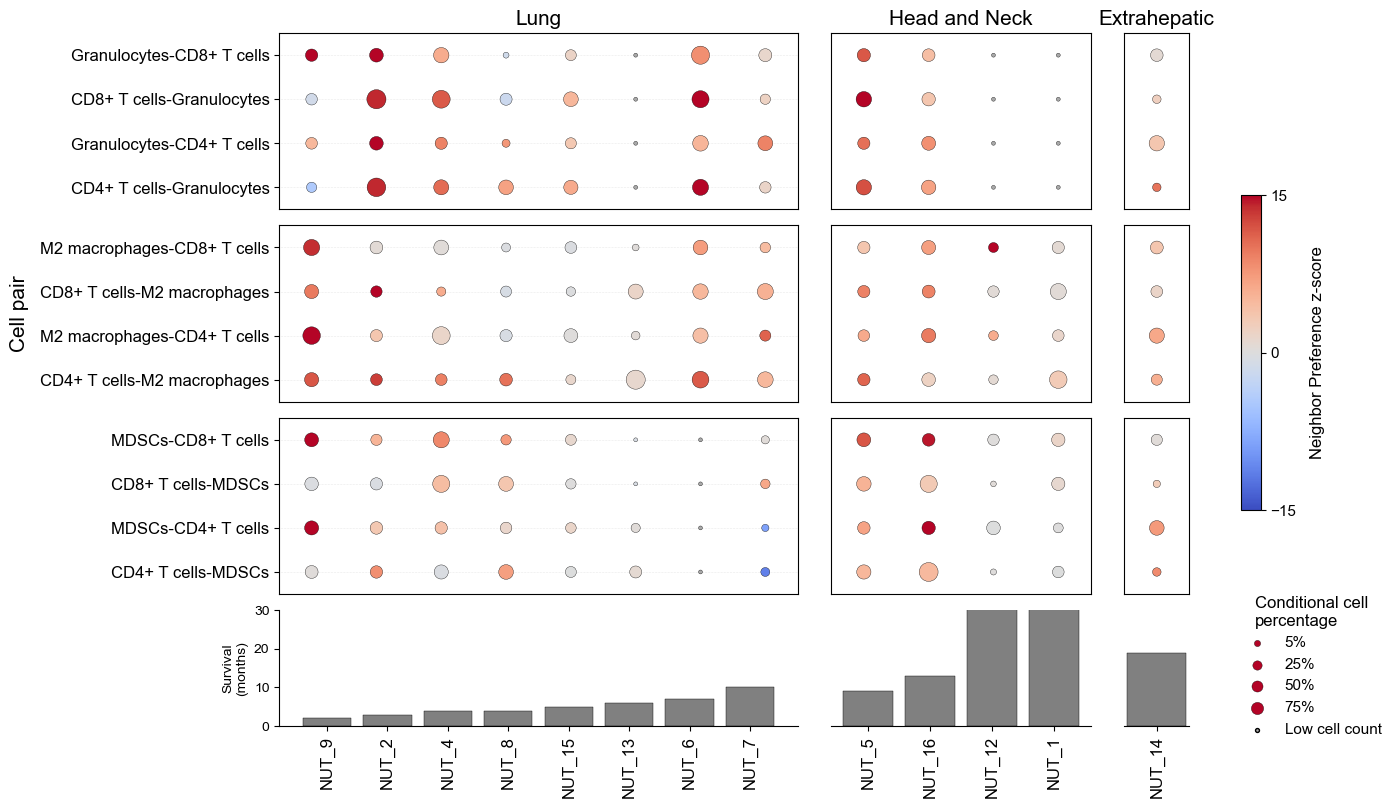

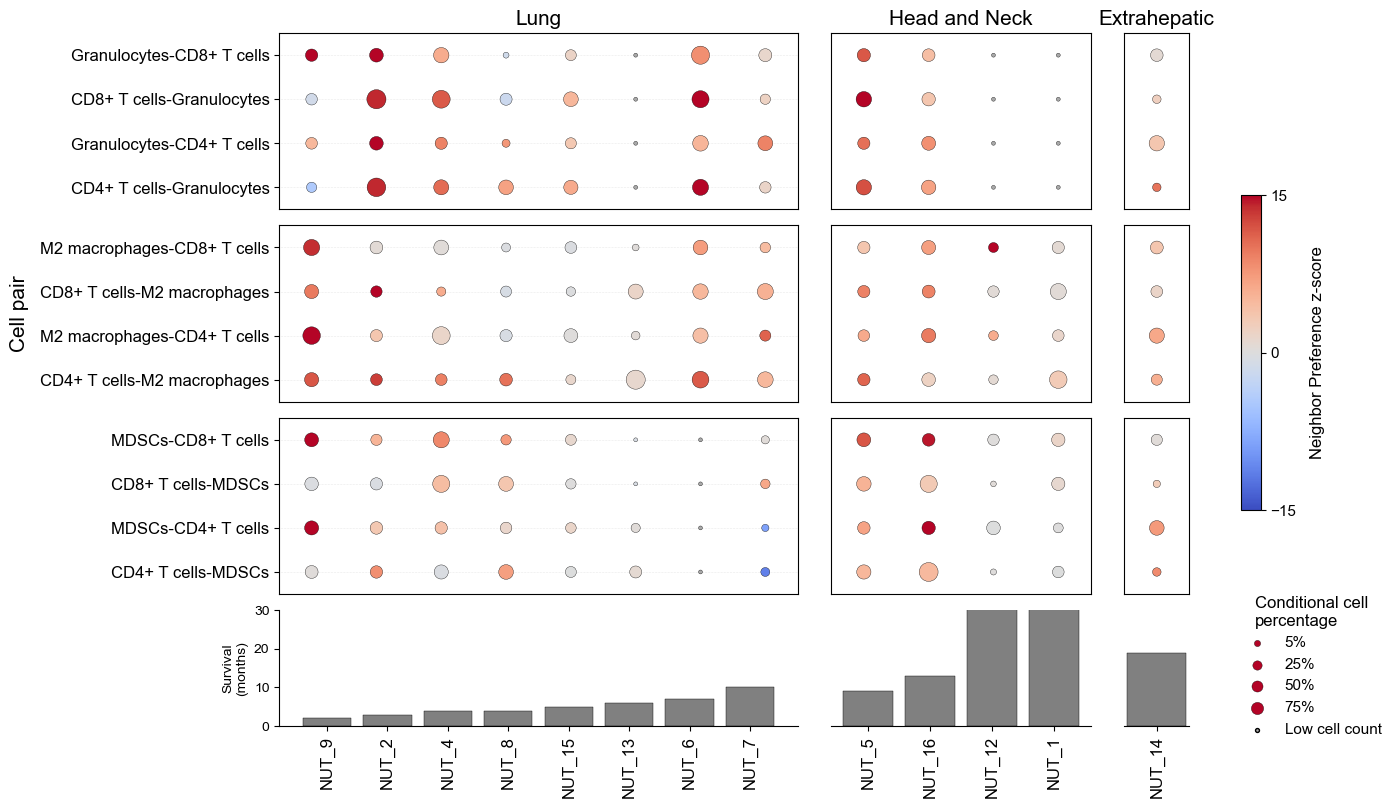

In [12]:
split_groups = {
  "Granulocytes": [
        "Granulocytes-CD8+ T cells", "CD8+ T cells-Granulocytes",
        "Granulocytes-CD4+ T cells", "CD4+ T cells-Granulocytes",
    ],
    "M2 macrophages": [
        "M2 macrophages-CD8+ T cells", "CD8+ T cells-M2 macrophages",
        "M2 macrophages-CD4+ T cells", "CD4+ T cells-M2 macrophages",
    ],
        "MDSCs": [
        "MDSCs-CD8+ T cells", "CD8+ T cells-MDSCs",
        "MDSCs-CD4+ T cells", "CD4+ T cells-MDSCs",
    ],
}

cozi_dotplot_facet_split(
    myeloid_t,
    column_name="cell_pair",
    zscore_col="zscore",
    patient_col="patient_ID",
    split_groups=split_groups,
    group_gap=0.1,
    survival_data=survival_data,
    survival_col="survival_time_months",
    tumor_site_col="tumor_site",
    survival_ylim=(0, 30),
    vmin=-15,
    vmax=15,
    figsize=(13, 9),
    site_width_ratios=[4, 2, 0.5],
    show_legend=True,
    save_path=os.path.join(results_dir, "myeloid_cd8_cd4_colocalization_dotplot_by_site.pdf")
)

# For Figure 6 B

/Users/jawadalaaedeen/Desktop/PhD/NMC/NUT_spatial/cozi/utils/cozi_dotplot.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  surv_df.groupby(tumor_site_col)
/Users/jawadalaaedeen/Desktop/PhD/NMC/NUT_spatial/cozi/utils/cozi_dotplot.py:68: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values(survival_col)[patient_col].tolist())
/Users/jawadalaaedeen/Desktop/PhD/NMC/NUT_spatial/cozi/utils/cozi_dotplot.py:183: UserWarning: Attempting to set identical low and high xlims makes transformation s

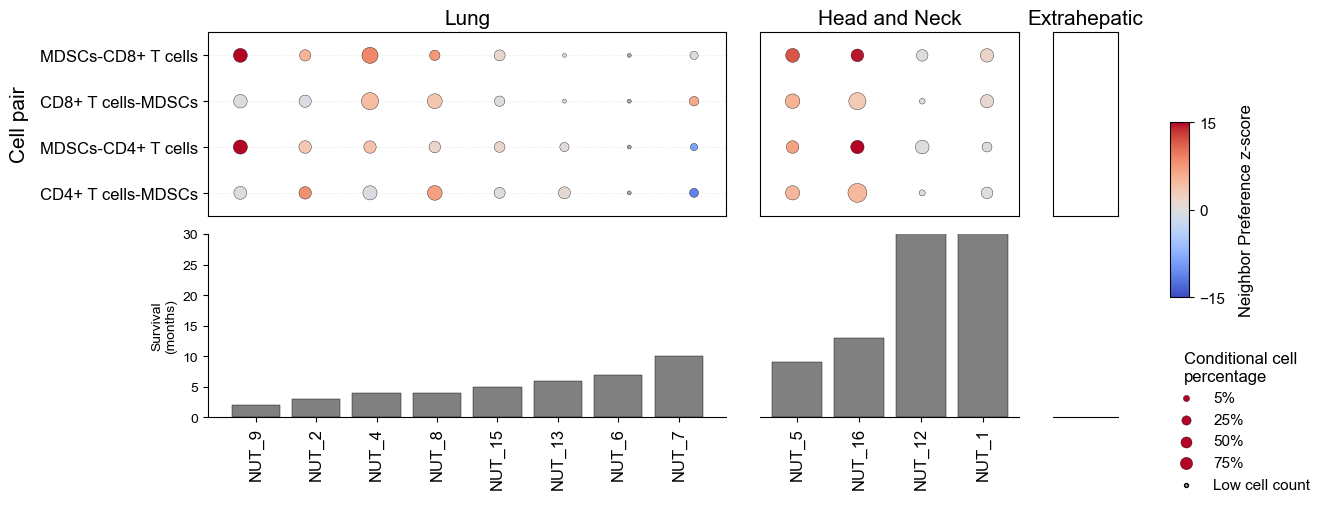

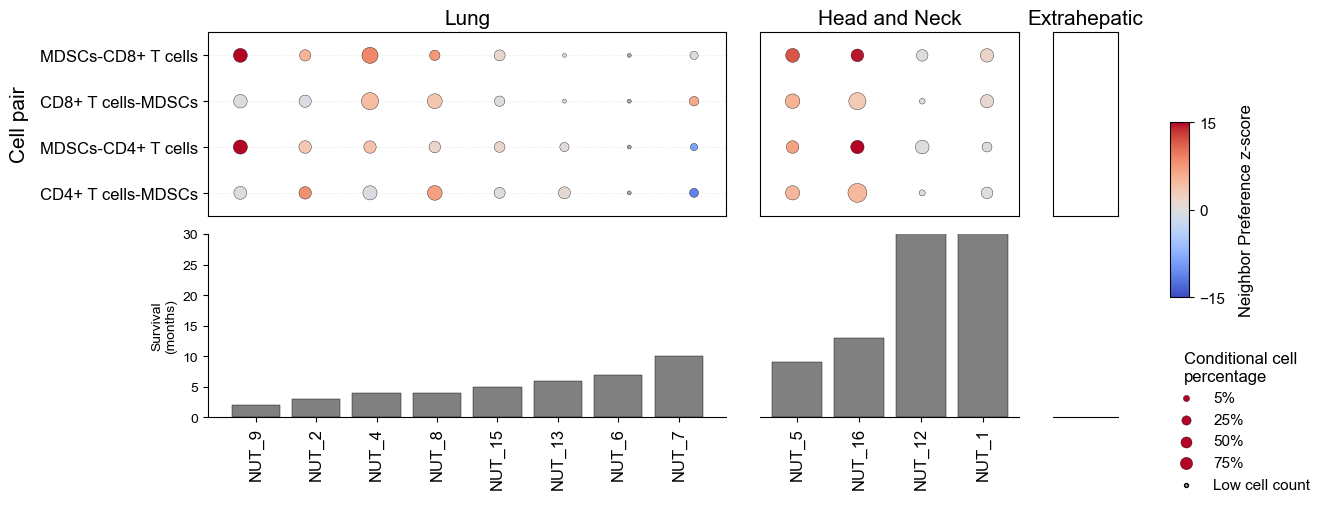

In [15]:
myeloid_t_selected = myeloid_t[myeloid_t["cell_pair"].isin(["MDSCs-CD8+ T cells", "CD8+ T cells-MDSCs", "MDSCs-CD4+ T cells", "CD4+ T cells-MDSCs"])].copy()
myeloid_t_selected

split_groups = {
        "MDSCs": [
        "MDSCs-CD8+ T cells", "CD8+ T cells-MDSCs",
        "MDSCs-CD4+ T cells", "CD4+ T cells-MDSCs"
    ]
}



cozi_dotplot_facet_split(
    myeloid_t_selected,
    column_name="cell_pair",
    zscore_col="zscore",
    patient_col="patient_ID",
    split_groups=split_groups,
    group_gap=0.1,
    survival_data=survival_data,
    survival_col="survival_time_months",
    tumor_site_col="tumor_site",
    survival_ylim=(0, 30),
    surv_height=0.5,
    vmin=-15,
    vmax=15,
    figsize=(13, 5),
    site_width_ratios=[4, 2, 0.5],
    show_legend=True,
    save_path=os.path.join(results_dir, "mdscs_cd8_cd4_colocalization_dotplot_by_site.pdf")
)

## For POSTER

In [14]:
myeloid_t_poster = myeloid_t[myeloid_t["cell_pair"].isin(["MDSCs-CD8+ T cells", "CD8+ T cells-MDSCs"])].copy()
myeloid_t_poster

,patient_ID,cell_pair,zscore,zscore_normalized,cond_percent,celltype_A,celltype_B
0,NUT_9,MDSCs-CD8+ T cells,22.905774,0.110960,11.227380,MDSCs,CD8+ T cells
1,NUT_9,CD8+ T cells-MDSCs,-0.270151,-0.004204,10.052007,CD8+ T cells,MDSCs
12,NUT_2,MDSCs-CD8+ T cells,5.295541,0.035745,4.787234,MDSCs,CD8+ T cells
13,NUT_2,CD8+ T cells-MDSCs,-0.399373,-0.002696,6.703911,CD8+ T cells,MDSCs
24,NUT_4,MDSCs-CD8+ T cells,8.738398,0.056134,20.029455,MDSCs,CD8+ T cells
25,NUT_4,CD8+ T cells-MDSCs,4.513425,0.028994,25.266904,CD8+ T cells,MDSCs
36,NUT_8,MDSCs-CD8+ T cells,7.607498,0.048150,3.453237,MDSCs,CD8+ T cells
37,NUT_8,CD8+ T cells-MDSCs,3.612091,0.022862,14.556962,CD8+ T cells,MDSCs
48,NUT_15,MDSCs-CD8+ T cells,1.184290,0.009448,4.313544,MDSCs,CD8+ T cells
49,NUT_15,CD8+ T cells-MDSCs,0.055634,-0.000104,3.486255,CD8+ T cells,MDSCs


/Users/jawadalaaedeen/Desktop/PhD/NMC/NUT_spatial/cozi/utils/cozi_dotplot.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  surv_df.groupby(tumor_site_col)
/Users/jawadalaaedeen/Desktop/PhD/NMC/NUT_spatial/cozi/utils/cozi_dotplot.py:68: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values(survival_col)[patient_col].tolist())


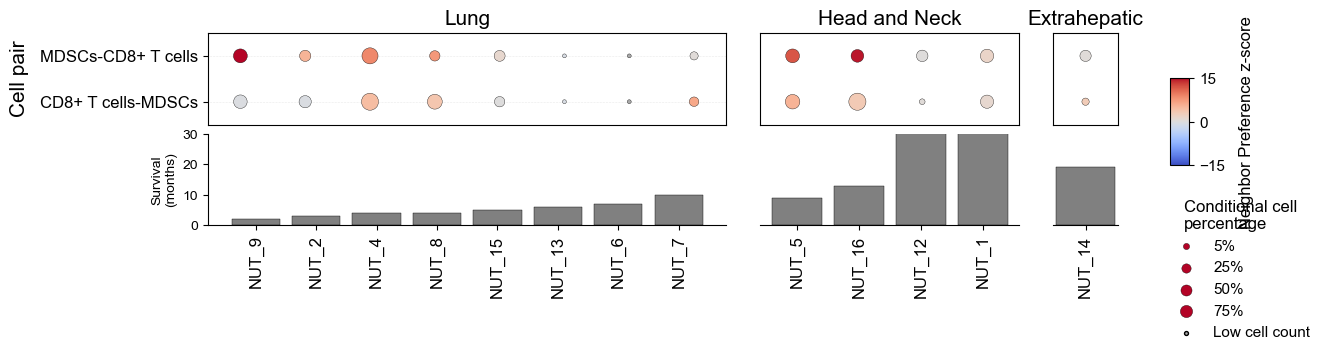

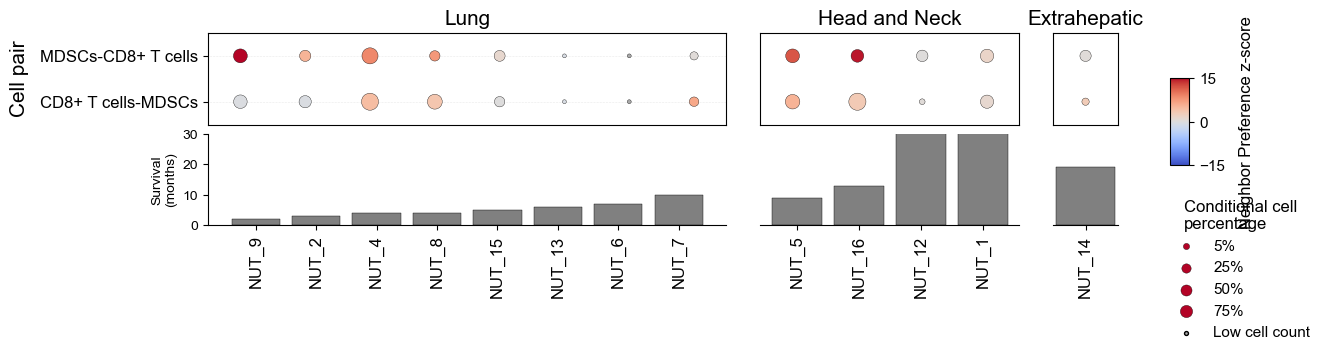

In [20]:
split_groups = {
        "MDSCs": [
        "MDSCs-CD8+ T cells", "CD8+ T cells-MDSCs",
    ]
}



cozi_dotplot_facet_split(
    myeloid_t_poster,
    column_name="cell_pair",
    zscore_col="zscore",
    patient_col="patient_ID",
    split_groups=split_groups,
    group_gap=0.1,
    survival_data=survival_data,
    survival_col="survival_time_months",
    tumor_site_col="tumor_site",
    survival_ylim=(0, 30),
    surv_height=0.5,
    vmin=-15,
    vmax=15,
    figsize=(13, 2.5),
    site_width_ratios=[4, 2, 0.5],
    show_legend=True,
    save_path=os.path.join(results_dir, "mdscs_cd8_colocalization_dotplot_by_site.pdf")
)